# Stellar Evolution in the ρ-T Plane

```{note}
This example uses the same models as the previous example.  You can download
them following the instructions there.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader as mr

We'll use a simple container to hold the models to allow us to explore them.

In [2]:
class Model:
    def __init__(self, mass, profiles=None, history=None):
        self.mass = mass
        if history:
            self.history = mr.MesaData(history)
        self.profiles = []
        if profiles:
            for p in profiles:
                self.profiles.append(mr.MesaData(p))

Now read in all the data.  For all but the lowest mass we have 2 profiles and 1 history.  The profiles were picked to roughly correspond to the midpoint of core H burning and core He burning.

In [3]:
models = []

models.append(Model(0.3, profiles=["M0.3_default_profile8.data"],
                    history="M0.3_default_trimmed_history.data"))

models.append(Model(1, profiles=["M1_default_profile8.data",
                                 "M1_default_profile218.data"],
                    history="M1_default_trimmed_history.data"))

models.append(Model(8, profiles=["M8_basic_co_profile8.data",
                                 "M8_basic_co_profile39.data"],
                    history="M8_basic_co_trimmed_history.data"))

models.append(Model(15, profiles=["M15_aprox21_profile8.data",
                                  "M15_aprox21_profile19.data"],
                    history="M15_aprox21_trimmed_history.data"))

## HR diagram

Let's start by looking at the models on the HR diagram and mark the location where
H burning is occuring (with an $\times$)

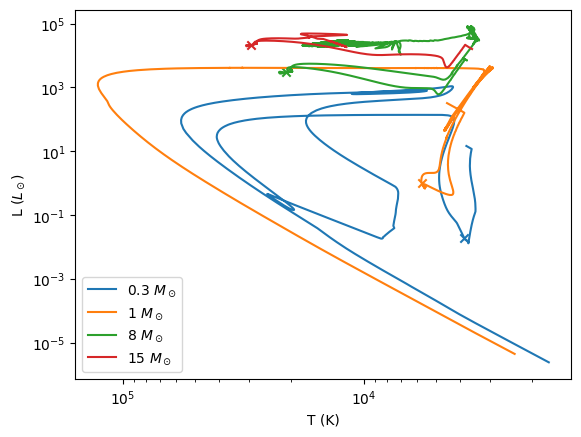

In [11]:
fig, ax = plt.subplots()

for star in models:
    ax.loglog(star.history.Teff, star.history.L,
              label=rf"{star.mass} $M_\odot$")
    ax.scatter([star.profiles[0].Teff], [star.profiles[0].photosphere_L], marker="x")

ax.legend()
ax.set_xlabel("T (K)")
ax.set_ylabel(r"L ($L_\odot$)")
ax.invert_xaxis()

You can see the main sequence clearly on this plot.

We also see that only the 0.3 and 1 solar mass stars "finished' stellar evolution, winding up as a cooling white dwarf at the end -- the path they follow is essentially a line of constant radius, since the white dwarf does not contract as it cools (it is degenerate).

## Central evolution

We want to plot the history of the evolution of the central conditions  in the $\log \rho$-$\log T$ plane.

We will plot the EOS boundary lines considered before.  These
functions are now in a module, [regimes.py](regimes.py) to make our life easier.

In [12]:
import regimes

Now we can plot the data

(100000.0, 1000000000.0)

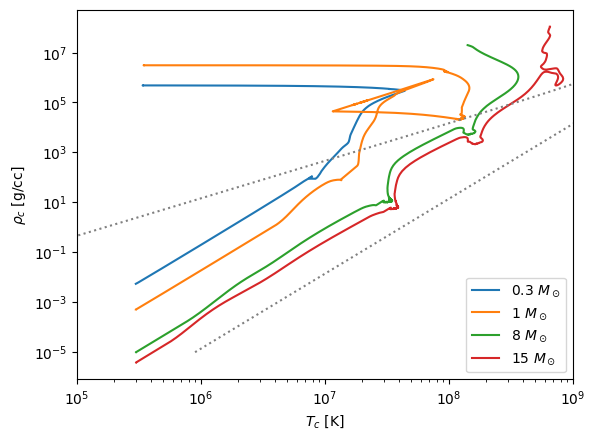

In [13]:
fig, ax = plt.subplots()

for star in models:
    ax.loglog(star.history.center_T, star.history.center_Rho,
              label=rf"{star.mass} $M_\odot$")

rho = np.logspace(-5, 8, 100)
ax.loglog(regimes.deg_ideal(rho, mu_e=1.3), rho, color="0.5", ls=":")
ax.loglog(regimes.rad_ideal(rho, mu=0.6), rho, color="0.5", ls=":")
ax.legend()

ax.set_xlabel(r"$T_c$ [K]")
ax.set_ylabel(r"$\rho_c$ [g/cc]")

ax.set_xlim(1.e5, 1.e9)

Some observations:

* The higher mass stars are closer to the line where radiation dominates.
* The 0.3 and 1 solar mass stars make a transition from following $T \approx \rho^{1/3}$ to $\rho = \mbox{constant}$ when degeneracy kicks in.
* The other stars more or less follow the $T \approx \rho^{1/3}$ trend expected from polytropes + ideal gas.


We can also add approximate ignition curves, by setting

$$\epsilon = \epsilon_\mathrm{min}$$

where we use $\epsilon_\mathrm{min} = 10^3~\mathrm{erg~g^{-1}~s^{-1}}$.

In [14]:
T_H = np.logspace(6.8, 7.5, 100)
rho_H = regimes.q_H(T_H)

T_He = np.logspace(7.9, 8.3, 100)
rho_He = regimes.q_He(T_He)

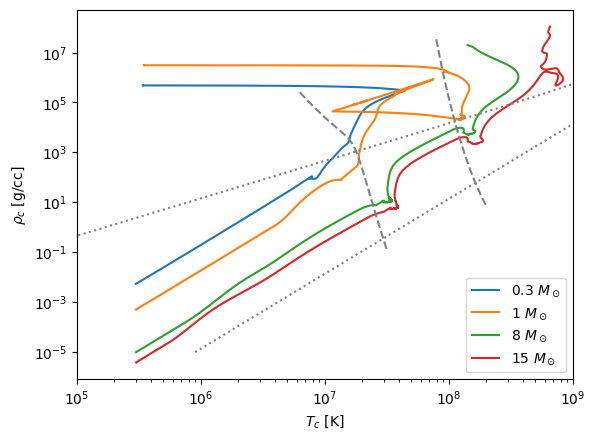

In [15]:
ax.plot(T_H, rho_H, ls="--", color="0.5")
ax.plot(T_He, rho_He, ls="--", color="0.5")

fig

We see that the 0.3 $M_\odot$ star never gets hot enough for He burning, while the 1.0 $M_\odot$ star ignites He under degenerate conditions (a He flash)

## Profiles 

Let's next look at the profiles of the stars in the $\log \rho$-$\log T$ plane

### 0.3 $M_\odot$

(1000.0, 1000000000.0)

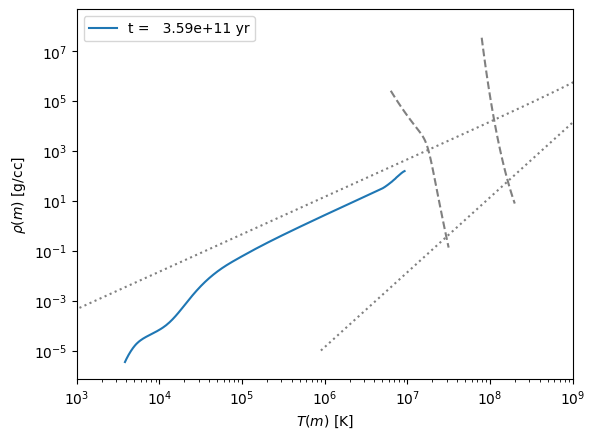

In [16]:
fig, ax = plt.subplots()

for p in models[0].profiles:
    ax.plot(p.T, p.Rho, label=f"t = {p.star_age:10.3g} yr")

ax.loglog(regimes.deg_ideal(rho, mu_e=1.3), rho, color="0.5", ls=":")
ax.loglog(regimes.rad_ideal(rho, mu=0.6), rho, color="0.5", ls=":")
ax.legend()

ax.plot(T_H, rho_H, ls="--", color="0.5")
ax.plot(T_He, rho_He, ls="--", color="0.5")

ax.set_xlabel(r"$T(m)$ [K]")
ax.set_ylabel(r"$\rho(m)$ [g/cc]")

ax.set_xlim(1.e3, 1.e9)

### 1 $M_\odot$

(1000.0, 1000000000.0)

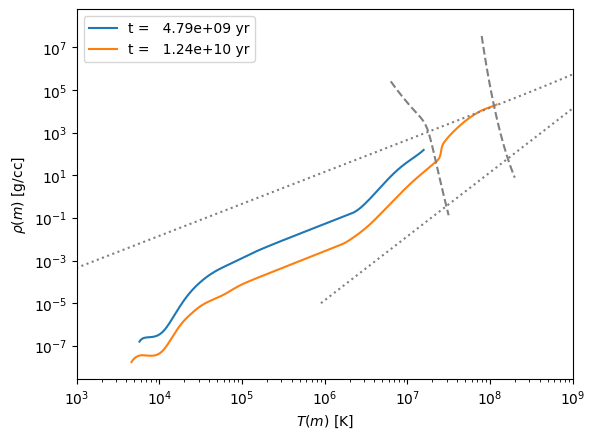

In [17]:
fig, ax = plt.subplots()

for p in models[1].profiles:
    ax.plot(p.T, p.Rho, label=f"t = {p.star_age:10.3g} yr")

ax.loglog(regimes.deg_ideal(rho, mu_e=1.3), rho, color="0.5", ls=":")
ax.loglog(regimes.rad_ideal(rho, mu=0.6), rho, color="0.5", ls=":")
ax.legend()

ax.plot(T_H, rho_H, ls="--", color="0.5")
ax.plot(T_He, rho_He, ls="--", color="0.5")

ax.set_xlabel(r"$T(m)$ [K]")
ax.set_ylabel(r"$\rho(m)$ [g/cc]")

ax.set_xlim(1.e3, 1.e9)

### 8 $M_\odot$

(1000.0, 1000000000.0)

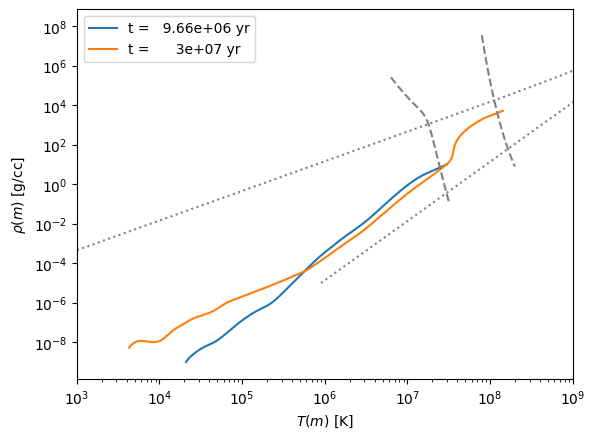

In [18]:
fig, ax = plt.subplots()

for p in models[2].profiles:
    ax.plot(p.T, p.Rho, label=f"t = {p.star_age:10.3g} yr")

ax.loglog(regimes.deg_ideal(rho, mu_e=1.3), rho, color="0.5", ls=":")
ax.loglog(regimes.rad_ideal(rho, mu=0.6), rho, color="0.5", ls=":")
ax.legend()

ax.plot(T_H, rho_H, ls="--", color="0.5")
ax.plot(T_He, rho_He, ls="--", color="0.5")

ax.set_xlabel(r"$T(m)$ [K]")
ax.set_ylabel(r"$\rho(m)$ [g/cc]")

ax.set_xlim(1.e3, 1.e9)

### 15 $M_\odot$

(1000.0, 1000000000.0)

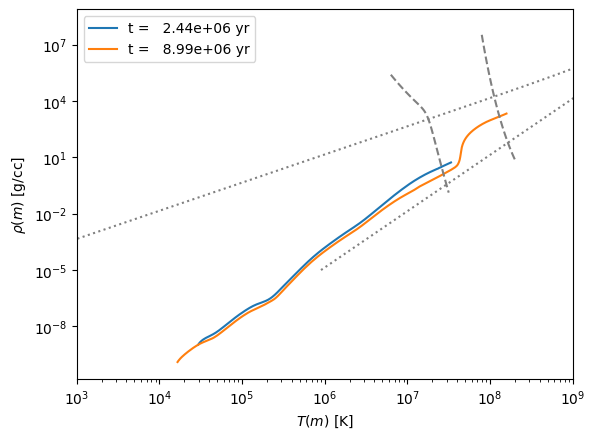

In [20]:
fig, ax = plt.subplots()

for p in models[3].profiles:
    ax.plot(p.T, p.Rho, label=f"t = {p.star_age:10.3g} yr")

ax.loglog(regimes.deg_ideal(rho, mu_e=1.3), rho, color="0.5", ls=":")
ax.loglog(regimes.rad_ideal(rho, mu=0.6), rho, color="0.5", ls=":")
ax.legend()

ax.plot(T_H, rho_H, ls="--", color="0.5")
ax.plot(T_He, rho_He, ls="--", color="0.5")

ax.set_xlabel(r"$T(m)$ [K]")
ax.set_ylabel(r"$\rho(m)$ [g/cc]")

ax.set_xlim(1.e3, 1.e9)